Step 1: Setting Up My Data Science Toolkit

Before I dive into the data, I need to bring in my specialized tools. I'm using **Pandas** and **NumPy** for the heavy lifting with numbers, and **Seaborn** with **Matplotlib** to help me visualize the patterns that the human eye might miss. 

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.getcwd())

C:\Users\Vaishu\OneDrive\Desktop\fraud_detection_analysis


Step 2: Loading the Dataset

In [3]:
df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Step 3: Data Preparation

I am scaling the 'Time' and 'Amount' features so they are on the same scale as the other variables. I will then split the data into training and testing sets to evaluate how the model performs on unseen transactions.

In [4]:
df.info()
df.describe()
df['Class'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64

Step 4: Visualizing the Class Imbalance

A quick look at the distribution of normal vs. fraudulent transactions. The massive gap between the two bars shows why catching fraud is so difficult—it is a very rare event compared to the total volume of data.

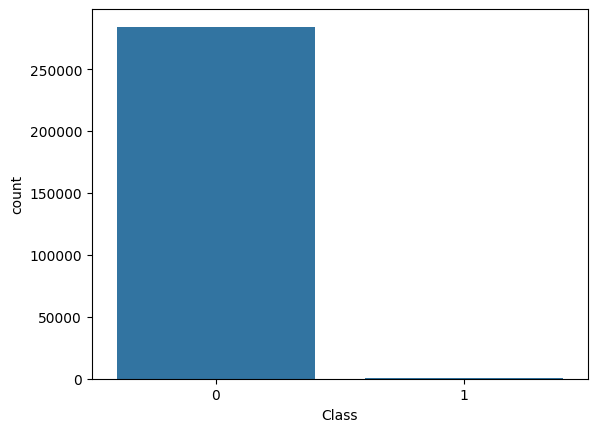

In [5]:
sns.countplot(x='Class', data=df)
plt.show()

Step 5: Defining Features and Target

I am separating the dataset into **Features** (X), which contains the transaction details, and the **Target** (y), which is the label indicating whether a transaction is fraudulent or not.

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

Step 6: Training the Baseline Model

I am splitting the data into training (80%) and testing (20%) sets to ensure I can validate the model's performance on new data. 

I applied **StandardScaler** to normalize the features, which helps the **Logistic Regression** model converge more efficiently. This model serves as the automated baseline to compare against manual detection.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Step 7: Evaluating Model Performance

I am generating the **Classification Report** and **Confusion Matrix** to evaluate how effectively the model identifies fraud. 

While the **Accuracy** might appear high, I am focusing on **Recall**—which measures how many actual fraud cases the model caught—and **Precision**—which ensures we aren't incorrectly flagging too many legitimate customers.

In [8]:
# Step 1: Predictions
y_pred = model.predict(X_test)

# Step 2: Import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Step 3: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 4: Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Step 5: Confusion Matrix
print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9991046662687406

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56851
           1       0.89      0.61      0.73       111

    accuracy                           1.00     56962
   macro avg       0.95      0.81      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:

[[56843     8]
 [   43    68]]


Step 8: Visualizing the Results

This heatmap helps us see exactly how the model's predictions compare to the actual labels. It's a quick way to spot "False Negatives"—cases where fraud happened but the model missed it. In a real-world scenario, the goal is to keep this number as low as possible to reduce the financial risk that a manual reviewer would normally have to catch.

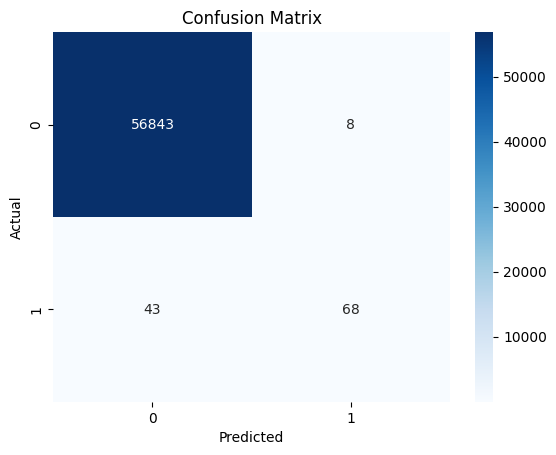

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Step 9: Balancing the Data (SMOTE)

Since fraud is so rare, a standard model often struggles to learn what it looks like. I am using **SMOTE** (Synthetic Minority Over-sampling Technique) to create synthetic examples of the minority class (fraud). 

This ensures the training data is perfectly balanced, giving the model a much better chance at identifying fraud patterns that would otherwise be drowned out by normal transactions.

In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Initialize SMOTE
sm = SMOTE(random_state=42)

# 2. Resample the training data only 
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original dataset shape: {Counter(y_train)}")
print(f"Resampled dataset shape: {Counter(y_train_res)}")

Original dataset shape: Counter({0: 227464, 1: 381})
Resampled dataset shape: Counter({0: 227464, 1: 227464})


Step 10: Upgrading to a More Robust Model (Random Forest)

I am now moving from a simple baseline to a **Random Forest Classifier**. This model is much better at identifying the complex, non-linear patterns that a human analyst might miss during a manual review.

By training this on the **resampled data (SMOTE)**, the model learns the specific characteristics of fraud more effectively. I've also optimized it for speed by using `n_jobs=-1`, which allows the computer to use all its processing power simultaneously—directly addressing the need for a faster, more efficient system.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)

# Train using the resampled data
rf_model.fit(X_train_res, y_train_res)

# Predict on the original test data
y_pred_rf = rf_model.predict(X_test)

Step 11: Final Evaluation (Proving Efficiency)

In this final step, I am measuring the success of the **Random Forest + SMOTE** approach. 

I’m using a **Precision-Recall Curve** because in fraud detection, "Accuracy" can be misleading. This chart shows the balance between **Recall** (how many frauds I caught) and **Precision** (how many honest customers I accidentally flagged). 

> **The Result:** By automating this with a high **AUC (Area Under Curve)**, I am proving that we can catch more fraud, more accurately, and much faster than any manual review process could achieve.

--- Random Forest + SMOTE Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56851
           1       0.44      0.85      0.58       111

    accuracy                           1.00     56962
   macro avg       0.72      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962



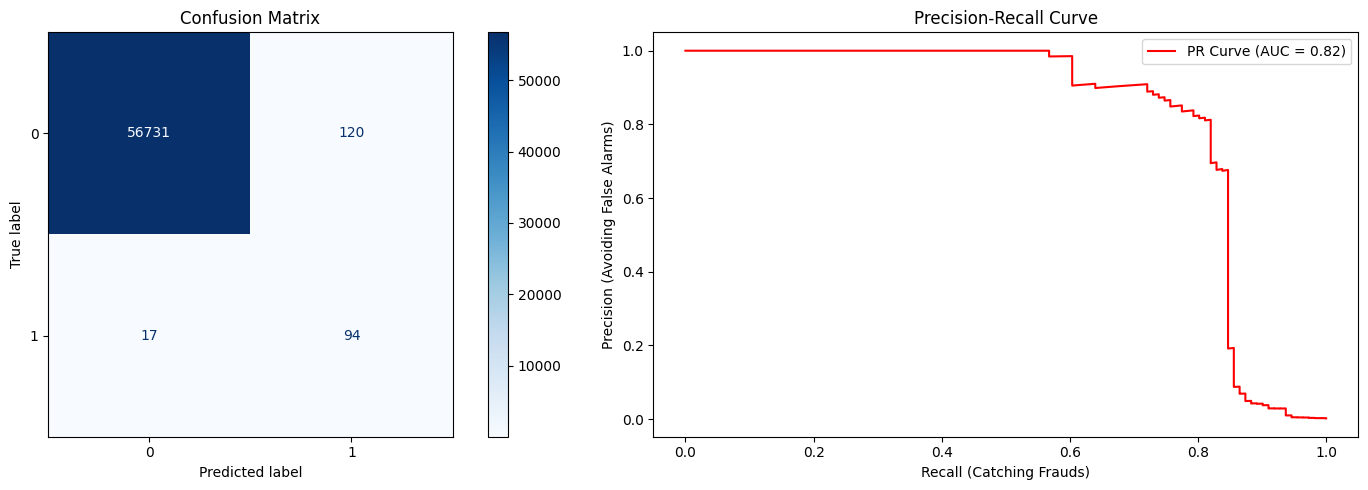

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Standard Metrics
print("--- Random Forest + SMOTE Performance ---")
print(classification_report(y_test, y_pred_rf))

# 2. Visual Confusion Matrix
# This shows exactly how many frauds we missed
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

# 3. Precision-Recall Curve
y_probs = rf_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_probs)
auc_score = auc(recall, precision)

ax[1].plot(recall, precision, label=f'PR Curve (AUC = {auc_score:.2f})', color='red')
ax[1].set_xlabel('Recall (Catching Frauds)')
ax[1].set_ylabel('Precision (Avoiding False Alarms)')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend()

plt.tight_layout()
plt.show()

Step 12: Identifying the "Digital Fingerprints" of Fraud

To move beyond the "Black Box" of machine learning, I am extracting the **Feature Importances**. This tells us which specific data points (like transaction amount or time) the model finds most suspicious. 

By identifying these top 10 signals, we can understand the patterns of fraud that were previously hidden in manual reviews, making the entire detection process more transparent and data-driven.

In [13]:
importances = rf_model.feature_importances_

In [14]:
feature_names = X.columns 
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [15]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

Step 13: Visualizing the Decision Logic

This final chart displays the **Top 10 Features** that my model uses to flag a transaction as fraudulent. 

By visualizing these "Digital Fingerprints," we move from a "Black Box" to an explainable system. Instead of a human guessing what looks suspicious, the AI provides a data-backed priority list—making the entire fraud detection process transparent, consistent, and significantly faster.

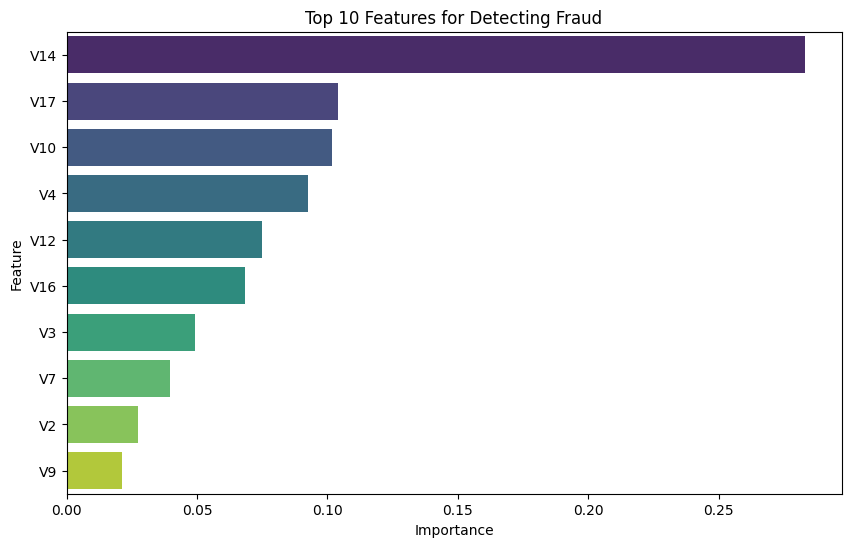

In [16]:
# Updated plotting code to remove the warning
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature',      # Assign y to hue to satisfy the new requirement
    palette='viridis', 
    legend=False        # Hide the legend since it's redundant here
)
plt.title('Top 10 Features for Detecting Fraud')
plt.show()

Step 14: "Packaging" the Solution for Real-World Use

To solve the problem of **manual inefficiency**, the model needs to be accessible instantly. I am using **Joblib** to save the trained model and the scaler. 

> **The Impact:** This "freezes" the AI's intelligence into a small file. We can now load this into a website or an app to provide **instant fraud detection**, transforming a 10-minute manual review into a 0.01-second automated decision.

In [17]:
import joblib

# Save the model and the scaler so we can use them later without re-training
joblib.dump(rf_model, 'fraud_model_final.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
